In [10]:
'''BASELINE MODELING - LINEAR REGRESSION
   Renewable Energy Production Dataset
   Capstone Project, Phase 3 (Baseline Model)'''

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

In [11]:
# 1. DATA LOADING
df = pd.read_csv("../Data/Cleaned/Cleaned_Production_Data.csv")
print(f"Dataset loaded: {len(df):,} rows, {len(df.columns)} columns")
df.head()

Dataset loaded: 51,862 rows, 31 columns


,Date,Start_Hour,End_Hour,Day_of_Year,Production,Temperature_C,Humidity_Percent,Precipitation_mm,WindSpeed_kmh,Source_Wind,...,Month_Name_February,Month_Name_January,Month_Name_July,Month_Name_June,Month_Name_March,Month_Name_May,Month_Name_November,Month_Name_October,Month_Name_September,Rainfall_Flag_Yes
0,2025-11-30,21,22,334,5281,11.8,72,0.0,5.9,1,...,0,0,0,0,0,0,1,0,0,0
1,2025-11-30,18,19,334,3824,13.5,67,0.0,7.2,1,...,0,0,0,0,0,0,1,0,0,0
2,2025-11-30,16,17,334,3824,17.3,50,0.0,5.1,1,...,0,0,0,0,0,0,1,0,0,0
3,2025-11-30,23,0,334,6120,10.4,69,0.0,5.4,1,...,0,0,0,0,0,0,1,0,0,0
4,2025-11-30,6,7,334,4387,8.2,62,0.0,1.6,1,...,0,0,0,0,0,0,1,0,0,0


In [12]:
# 2. FEATURE PREPARATION

# Date is dropped here - Day_of_Year, Month, and Season columns already
# only the time-based information is needed for modeling
df_model = df.drop(columns=["Date"])

# Splitting features (X) and target (y)
X = df_model.drop(columns=["Production"])
y = df_model["Production"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeatures used:")
print(X.columns.tolist())

Feature matrix shape: (51862, 29)
Target shape: (51862,)

Features used:
['Start_Hour', 'End_Hour', 'Day_of_Year', 'Temperature_C', 'Humidity_Percent', 'Precipitation_mm', 'WindSpeed_kmh', 'Source_Wind', 'Season_Spring', 'Season_Summer', 'Season_Winter', 'Day_Name_Monday', 'Day_Name_Saturday', 'Day_Name_Sunday', 'Day_Name_Thursday', 'Day_Name_Tuesday', 'Day_Name_Wednesday', 'Month_Name_August', 'Month_Name_December', 'Month_Name_February', 'Month_Name_January', 'Month_Name_July', 'Month_Name_June', 'Month_Name_March', 'Month_Name_May', 'Month_Name_November', 'Month_Name_October', 'Month_Name_September', 'Rainfall_Flag_Yes']


In [13]:
# 3. TRAIN/TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (41489, 29)
Testing set: (10373, 29)


In [14]:
# 4. FIT BASELINE MODEL: LINEAR REGRESSION
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred = lr_model.predict(X_test)

print("Model trained successfully")

Model trained successfully


In [15]:
# 5. MODEL EVALUATION
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Linear Regression Performance:")
print(f"  RMSE: {rmse:.2f} MWh")
print(f"  MAE:  {mae:.2f} MWh")
print(f"  R2:   {r2:.4f}")

Linear Regression Performance:
  RMSE: 3706.51 MWh
  MAE:  2938.41 MWh
  R2:   0.1277


**Insight about the evaluation metrics:** Weak baseline performance (R2 ~0.08) is expected here because target feature "Production" depends on non-linear, interactive patterns (e.g. Wind vs Solar behaving oppositely by season) that a linear model can't capture. This sets the benchmark for XGBoost/LightGBM to beat.

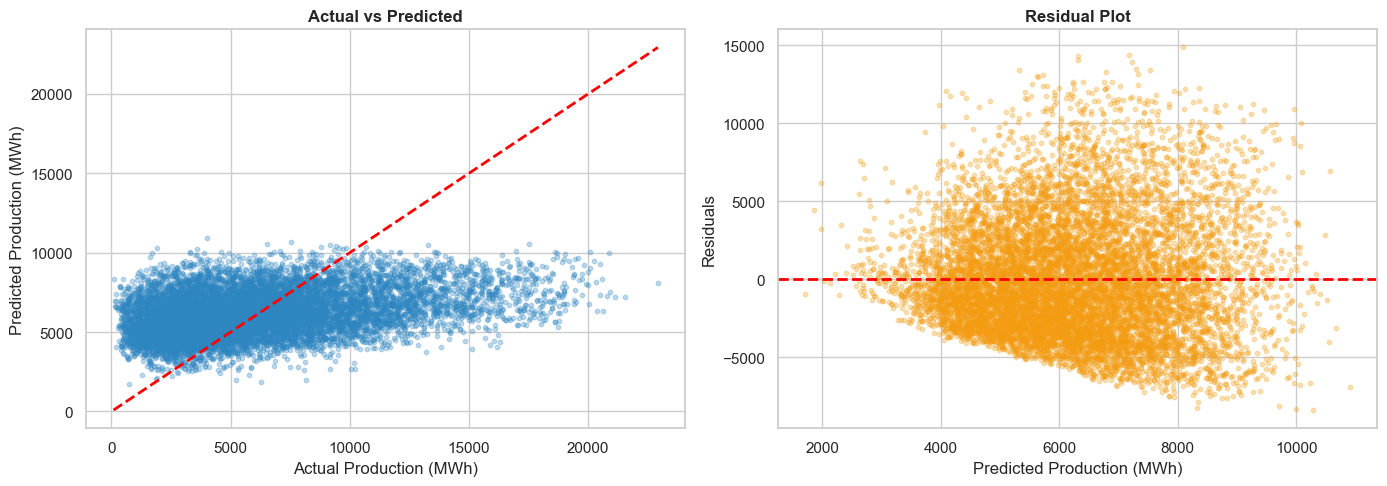

In [16]:
# 6. ACTUAL VS PREDICTED

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: actual vs predicted
axes[0].scatter(y_test, y_pred, alpha=0.3, color='#2E86C1', s=10)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             color='red', linewidth=2, linestyle='--')
axes[0].set_xlabel('Actual Production (MWh)')
axes[0].set_ylabel('Predicted Production (MWh)')
axes[0].set_title('Actual vs Predicted', fontweight='bold')

# Residuals
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.3, color='#F39C12', s=10)
axes[1].axhline(y=0, color='red', linewidth=2, linestyle='--')
axes[1].set_xlabel('Predicted Production (MWh)')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residual Plot', fontweight='bold')

plt.tight_layout()
os.makedirs('../Visualisations/Models', exist_ok=True)
plt.savefig('../Visualisations/Models/baseline_actual_vs_predicted(without weather).png', dpi=150, bbox_inches='tight')
plt.show()

**What the plots tell us:** Predictions cluster tightly around the mean instead of following the actual range. This is a classic sign of underfitting, consistent with a low R2 and confirming that a linear model is too simple for this data's non-linear structure.

In [17]:
# 7. FEATURE COEFFICIENTS
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr_model.coef_
}).sort_values(by="Coefficient", key=abs, ascending=False)

print("Top 10 features by coefficient magnitude:")
print(coef_df.head(10).to_string(index=False))

Top 10 features by coefficient magnitude:
             Feature  Coefficient
       Season_Winter  2640.339956
    Month_Name_March  2091.125570
Month_Name_September -2014.784491
       Season_Summer -1919.434828
      Month_Name_May -1658.906864
  Month_Name_January  1524.457881
 Month_Name_February  1503.509320
         Source_Wind  1190.908824
     Month_Name_June -1170.870886
 Month_Name_November  1124.299923


**Note:** Seasonal features dominate the top coefficients (Feb, Winter, Dec, Sept, Mar, Spring, Jan) rather than Start_Hour, confirming the EDA's finding that Wind is the strong winter peak and Solar's summer dip drive Production more than hour of day here.

In [18]:
# 8. SAVE RESULTS
results = pd.DataFrame({
    "Model": ["Linear Regression"],
    "RMSE": [rmse],
    "MAE": [mae],
    "R2": [r2]
})

results.to_csv("../Data/ModelResults/baseline_model_results(without weather).csv", index=False)
coef_df.to_csv("../Data/ModelResults/baseline_model_coefficients(without weather).csv", index=False)

print("Saved: Data/ModelResults/baseline_model_results(without weather).csv")
print("Saved: Data/ModelResults/baseline_model_coefficients(without weather).csv")
print("\nBaseline model complete. Ready to compare against boosting models (XGBoost/LightGBM).")

Saved: Data/ModelResults/baseline_model_results(without weather).csv
Saved: Data/ModelResults/baseline_model_coefficients(without weather).csv

Baseline model complete. Ready to compare against boosting models (XGBoost/LightGBM).
